# BTCUSDT M15 — 1D-CNN đa nhiệm trên CUDA

Input là 48 nến × 19 feature tối giản. Hai output là `HOLD/LONG/SHORT` và log Risk:R. Notebook **bắt buộc CUDA**, không tự chuyển về CPU.

In [1]:
from pathlib import Path
import sys, json
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT/'pipeline').exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
import torch
print('Python:', sys.executable)
print('PyTorch:', torch.__version__, '| built CUDA:', torch.version.cuda)
assert torch.cuda.is_available(), 'CUDA không khả dụng trong kernel này.'
print('GPU:', torch.cuda.get_device_name(0), '| VRAM MiB:', torch.cuda.get_device_properties(0).total_memory//1024**2)

Python: c:\Users\thanh\Documents\Codex\2026-09-08\t\outputs\btc-market-pipeline\.venv\Scripts\python.exe
PyTorch: 2.5.1+cu118 | built CUDA: 11.8
GPU: NVIDIA GeForce RTX 2050 | VRAM MiB: 4095


## Cấu hình

Các giá trị quan trọng để thử: `label_threshold`, `risk_floor`, `lookback`, `horizon`, `dropout`, `learning_rate`, `rr_loss_weight`. Mỗi lần đổi label/risk phải train lại từ đầu.

In [2]:
from pipeline.cnn_training import CNNConfig, FEATURE_NAMES, CLASS_NAMES, prepare_data, train_cuda
CONFIG = CNNConfig(
    lookback=48, horizon=4, label_threshold=0.004,
    risk_floor=0.0025, log_rr_clip=2.0,
    batch_size=512, epochs=15, patience=3,
    learning_rate=1e-3, weight_decay=1e-4,
    rr_loss_weight=0.30, dropout=0.25, seed=42,
)
DATA_PATH = PROJECT_ROOT/'artifacts'/'m15_analysis'/'BTCUSDT_15m_clean.csv'
OUTPUT_DIR = PROJECT_ROOT/'artifacts'/'m15_final_model'
print('Input shape:', CONFIG.lookback, '×', len(FEATURE_NAMES))
print('Features:', FEATURE_NAMES)

Input shape: 48 × 19
Features: ['co_return', 'high_shadow_return', 'low_shadow_return', 'candle_range_return', 'log_return_1', 'log_return_4', 'log_return_12', 'ema20_distance', 'ema200_distance_atr', 'atr14_pct', 'volatility_12', 'volatility_48', 'volume_log_ratio_1', 'volume_log_ratio_8', 'volume_zscore_48', 'position_in_range_48', 'rsi14_scaled', 'time_sin', 'time_cos']


## Feature tối giản

Đã bỏ các feature trùng ý nghĩa: body/range ratios phụ, nhiều EMA slope, EMA50/EMA100, nhiều cửa sổ volume/volatility, weekday và up-ratio. Giữ 19 feature thuộc 7 nhóm độc lập: hình nến, momentum, trend, volatility, volume, vị trí/RSI và giờ UTC.

In [3]:
_, features, labels, log_rr, future_return = prepare_data(DATA_PATH, CONFIG)
distribution = labels.map(dict(enumerate(CLASS_NAMES))).value_counts().to_frame('count')
distribution['pct'] = distribution['count']/len(labels)*100
display(distribution)
print('Feature rows:', features.shape, '| missing:', int(features.isna().sum().sum()))

,count,pct
HOLD,162874,69.306905
LONG,36899,15.701435
SHORT,35231,14.991660


Feature rows: (235004, 19) | missing: 0


## Train CUDA

Checkpoint tốt nhất được chọn bằng validation macro-F1. Early stopping tránh tiếp tục học khi validation không cải thiện.

In [4]:
model, scaler, results = train_cuda(DATA_PATH, OUTPUT_DIR, CONFIG)
print('Best/final validation macro-F1:', results['validation']['macro_f1'])
print('Test macro-F1:', results['test']['macro_f1'])
print('Test log-RR MAE:', results['test']['log_rr_mae'])
print('Risk baseline MAE:', results['test']['log_rr_median_baseline_mae'])

{'epoch': 1, 'train_loss': 1.0755529896131808, 'val_macro_f1': 0.43467248807050746, 'val_balanced_accuracy': 0.4370700748995467, 'val_log_rr_mae': 0.37640103697776794}
{'epoch': 2, 'train_loss': 1.0601564122466633, 'val_macro_f1': 0.44030332347207374, 'val_balanced_accuracy': 0.43690224755291135, 'val_log_rr_mae': 0.369884192943573}
{'epoch': 3, 'train_loss': 1.056450092755328, 'val_macro_f1': 0.4329394336192515, 'val_balanced_accuracy': 0.44973110796988847, 'val_log_rr_mae': 0.37017568945884705}
{'epoch': 4, 'train_loss': 1.0543337438786542, 'val_macro_f1': 0.43244599890718166, 'val_balanced_accuracy': 0.44162565385029184, 'val_log_rr_mae': 0.39145833253860474}
{'epoch': 5, 'train_loss': 1.0496015757640687, 'val_macro_f1': 0.4351512038978273, 'val_balanced_accuracy': 0.44874776046223636, 'val_log_rr_mae': 0.37545421719551086}
Best/final validation macro-F1: 0.44030332347207374
Test macro-F1: 0.4355045848188341
Test log-RR MAE: 0.36957281827926636
Risk baseline MAE: 0.3710513412952423


,train_loss,val_macro_f1,val_balanced_accuracy,val_log_rr_mae
epoch,,,,
1,1.075553,0.434672,0.437070,0.376401
2,1.060156,0.440303,0.436902,0.369884
3,1.056450,0.432939,0.449731,0.370176
4,1.054334,0.432446,0.441626,0.391458
5,1.049602,0.435151,0.448748,0.375454


,macro_f1,balanced_accuracy,accuracy,majority_macro_f1,log_rr_mae,log_rr_median_baseline_mae,confidence_policy,samples
validation,0.440303,0.436902,0.695174,0.286323,0.369884,0.373861,"{'0.4': {'signals': 2872, 'coverage': 0.081491...",35243
test,0.435505,0.432967,0.695285,0.287774,0.369573,0.371051,"{'0.4': {'signals': 2384, 'coverage': 0.067840...",35141



 VALIDATION


,precision,recall,f1-score,support
HOLD,0.823152,0.847198,0.835002,26531.000000
LONG,0.288825,0.242618,0.263713,4538.000000
SHORT,0.223515,0.220891,0.222195,4174.000000
accuracy,0.695174,0.695174,0.695174,0.695174
macro avg,0.445164,0.436902,0.440303,35243.000000
weighted avg,0.683333,0.695174,0.688863,35243.000000



 TEST


,precision,recall,f1-score,support
HOLD,0.826892,0.843312,0.835021,26690.000000
LONG,0.267041,0.228571,0.246313,4165.000000
SHORT,0.223370,0.227018,0.225179,4286.000000
accuracy,0.695285,0.695285,0.695285,0.695285
macro avg,0.439101,0.432967,0.435505,35141.000000
weighted avg,0.686928,0.695285,0.690866,35141.000000


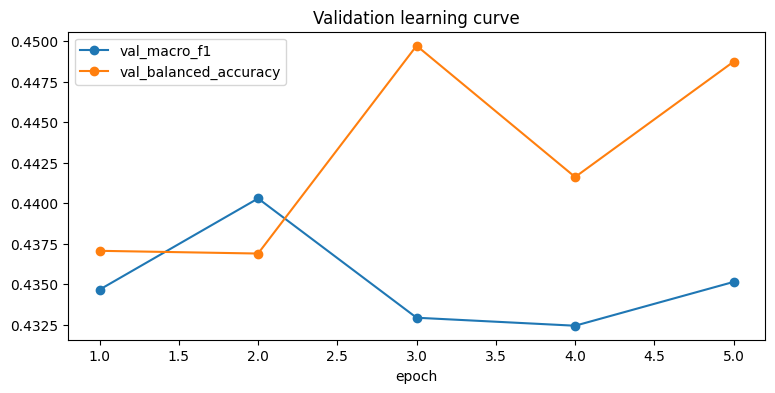

In [5]:
import pandas as pd
history = pd.DataFrame(results['history']).set_index('epoch')
display(history)
history[['val_macro_f1','val_balanced_accuracy']].plot(marker='o', figsize=(9,4), title='Validation learning curve');
display(pd.DataFrame([results['validation'],results['test']], index=['validation','test']).drop(columns=['confusion_matrix','classification_report']))
for split in ['validation','test']:
    print('\n',split.upper())
    display(pd.DataFrame(results[split]['classification_report']).T)

## Cách tinh chỉnh có kiểm soát

1. **Ngưỡng label:** thử `0.003`, `0.004`, `0.005`, `0.0075`. Ngưỡng thấp tăng số lệnh nhưng tăng nhiễu. Chọn theo validation macro-F1 và precision LONG/SHORT sau phí.
2. **Feature ablation:** lần lượt bỏ nhóm thời gian, RSI, EMA200, volume rồi train cùng seed. Chỉ giữ nhóm cải thiện validation qua nhiều split. Sửa `FEATURE_NAMES` và `engineer_features` trong `pipeline/cnn_training.py`.
3. **Risk:R:** thử `risk_floor` 0.002–0.004 và `log_rr_clip` 1.5–2.5. Head RR chỉ tốt khi MAE thấp hơn `log_rr_median_baseline_mae`.
4. **CNN:** thử channels nhỏ/lớn, dropout 0.15–0.40, learning rate `3e-4`–`2e-3`. RTX 2050 4 GB nên giữ batch 256–512.
5. **Lookback/horizon:** thử lookback 32/48/96 và horizon 2/4/8; embargo luôn bằng lookback+horizon.
6. **Tiêu chuẩn học thật:** validation gần test, macro-F1 vượt majority baseline, LONG/SHORT precision tăng, RR vượt baseline, và kết quả ổn định ở walk-forward.
7. **Không dùng test để chọn cấu hình.** Chỉ mở test sau khi đã chốt feature và hyperparameter bằng validation.